In [1]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.cosmology import Planck15
from astropy.table import Table
from astropy import constants as const
from astropy import units as u
from glob import glob
import h5py 
from timeit import default_timer as timer
import multiprocess

import os, sys
os.environ["XLA_FLAGS"] = "--xla_force_host_platform_device_count=64"
os.environ['XLA_PYTHON_CLIENT_PREALLOCATE'] = 'false' # for GPU 

from jax import config
config.update("jax_enable_x64", True)
import jax.numpy as jnp
from jax._src.third_party.scipy.interpolate import RegularGridInterpolator as jax_RegularGridInterpolator
from jax import jit, grad, vmap, pmap, debug, jvp, vjp, jacrev, jacfwd, make_jaxpr, hessian, value_and_grad
from jax_cosmo.scipy.interpolate import InterpolatedUnivariateSpline

from scipy.interpolate import InterpolatedUnivariateSpline as scipy_InterpolatedUnivariateSpline
from scipy.ndimage import gaussian_filter1d

from jax.experimental.ode import odeint
from jax.lax import fori_loop, while_loop
from jax.scipy.integrate import trapezoid

from diffrax import diffeqsolve, ODETerm, PIDController, SaveAt, Kvaerno3, Bosh3, Dopri5, Tsit5, DirectAdjoint, RecursiveCheckpointAdjoint, BacksolveAdjoint

from diffrax import backward_hermite_coefficients, CubicInterpolation

from functools import partial

from jax.random import PRNGKey, key

import numpyro
import numpyro.distributions as dist
from numpyro.examples.datasets import LYNXHARE, load_dataset
from numpyro.infer import MCMC, NUTS, Predictive, AIES, ESS

from jax.experimental import mesh_utils
from jax.experimental.shard_map import shard_map
from jax.sharding import Mesh, PartitionSpec, PositionalSharding, NamedSharding

import optax

import arviz as az
import seaborn as sns
import pandas as pd
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from chainconsumer import Chain, ChainConsumer, make_sample, PlotConfig, Truth, ChainConfig
from matplotlib.colors import Normalize
import matplotlib.gridspec as gridspec

plt.rcParams['figure.dpi'] = 120
plt.rcParams['ytick.right'] = True
plt.rcParams['xtick.top'] = True

In [72]:
### function that overplots marginal posteriors from multi-constraint runs 
# TO DO: generalize this for any number of free parameters, multi-constraint runtypes, number of chains, etc.
def marginals(output_path,basestr,savefig=False):
    ### output_path is the base sapphire output directory from config.yaml
    ### basestr should have %s in for chain num AND flag (111,110,etc.), e.g., 'numpyro_manga_chain%s_%s.npz'

    ### TO DO: automate this and/or have it become an input
    params_free = ["A_M","alpha0_M","A_E","alpha0_E","A_SF","alpha0_SF","A_Z","alpha0_Z"]
    parlabels = {'A_M':r'$A_M$','alpha0_M':r'$\alpha_M^0$',
                 'A_E':r'$A_E$','alpha0_E':r'$\alpha_E^0$',
                 'A_SF':r'$A_{\rm SF}$','alpha0_SF':r'$\alpha_{\rm SF}^0$',
                 'A_Z':r'$A_Z$','alpha0_Z':r'$\alpha_Z^0$'}
    parlims = {'A_M':(-2.1,1.1),'alpha0_M':(-2.1,0.1),
               'A_E':(-2.1,0.1),'alpha0_E':(-2.1,0.1),
               'A_SF':(-0.1,1.2),'alpha0_SF':(-2.1,0.1),
               'A_Z':(-2.1,0.1),'alpha0_Z':(-2.1,0.1)}

    # par_labels = [r'$A_M$',r'$\alpha_M^0$',r'$A_E$',r'$\alpha_E^0$',r'$A_{\rm SF}$',r'$\alpha_{\rm SF}^0$',r'$A_Z$',r'$\alpha_Z^0$']

    # initialize 2-row figure for the 8 parameters [TO DO: GENERALIZE THIS]
    fig, axes = plt.subplots(nrows=2,ncols=4,figsize=(13,5),constrained_layout=True)
    allax = np.ravel(axes)
    
    flag_colors = {'100':'teal','110':'indigo','111':'orange'}
    # flag_labels = {'100':r'SMHM','110':r'SMHM+f$_{\rm gas}$','111':r'SMHM+f$_{\rm gas}$+MZR'}
    flag_labels = {'100':r'SMHM','110':r'SMHM+f$_{\rm gas}$','111':r'SMHM+f$_{\rm gas}$+MZR'}
    
    ### loop over each realization flag 

    for flag in ['100','110','111']:

        flag_color = flag_colors[flag]
        flag_label = flag_labels[flag]

        ### loop over and store posterior samples from all 4 chains    
        # samples dataframes indexed by int for chain_num for Gelman-Rubin statistic 
        chain_samples = {}

        # TO DO: generalize depending on actual # of chains
        for cnum in range(0,4):

            # TO DO: generalize this beyond numpyro_manga_chain%s_%s.npz
            fname = os.path.join(output_path,'outputs',basestr%(cnum,flag))
            npz_nuts = jnp.load(fname,allow_pickle=True)
        
            samples_dict = {k: npz_nuts['samples'].item()[k] for k in params_free}
            samples_df = pd.DataFrame(samples_dict)
            chain_samples[cnum] = samples_df

        # combine the different chains' posterior samples
        samples_df = pd.concat(chain_samples.values(), ignore_index=True)  

        # plot this realization's posterior for each parameter in its respective subplot
        for i,k in enumerate(parlabels.keys()):

            sns.kdeplot(samples_df[k].values,color=flag_color,ax=allax[i],lw=3,alpha=0.7,label=flag_label)
            allax[i].set_xlim(parlims[k])
            allax[i].set_xlabel(parlabels[k],fontsize=16)
            allax[i].set_ylabel('Posterior',fontsize=14)

    leg = allax[2].legend(fancybox=True)
    
    
    if savefig is True:
        outfile = os.path.join(output_path,'figures',
                               # since this is run dependent, for now just prepend "trace" to original filename 
                               # e.g., numpyro_manga_chain%s_111.npz becomes trace_numpyro_manga_111.png
                               # TO DO: how to improve/generalize this?
                              'marginals_'+(basestr.replace('_chain%s','').replace('_%s','').replace('.npz','.png')))
        plt.savefig(outfile,bbox_inches='tight',dpi=300,facecolor='w')
        print('saved %s'%outfile,flush=True)




saved /mnt/ceph/users/vpandya/sapphire_outputs/figures/marginals_numpyro_manga.png


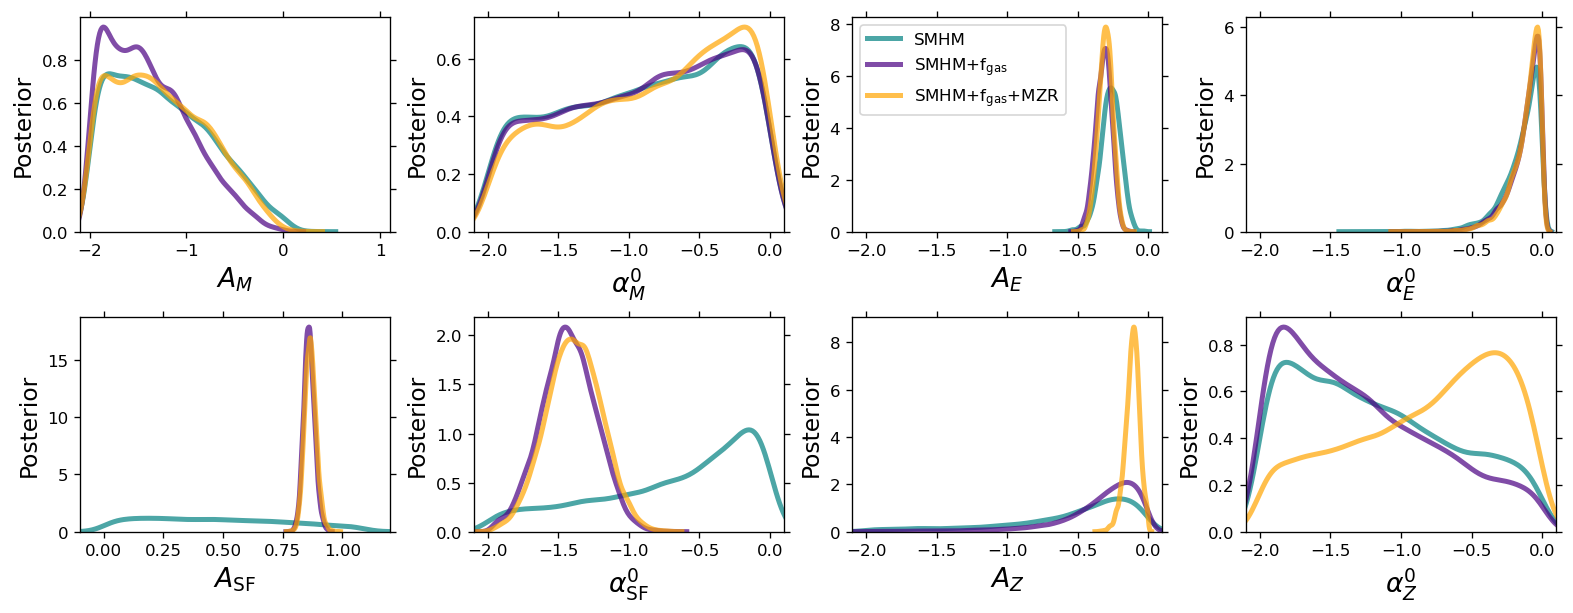

In [73]:
marginals('/mnt/ceph/users/vpandya/sapphire_outputs','numpyro_manga_chain%s_%s.npz',True)